In [1]:
from pylib.preamble import *
enable_autoreload()

# *Fetch* and *assess* data form eurostat

## 1. `Fetch`

### 1. Rise of electrification

As per: https://ec.europa.eu/eurostat/databrowser/view/nrg_ind_re/default/table?lang=en

In [2]:
# aggregate
df_a = fetch(nrg_bal=var_groups.total)

# main categories
df_m = fetch(nrg_bal=var_groups.parent)

# subs
df_s = fetch(nrg_bal=var_groups.subs)

### 2. Industries

As per: https://ec.europa.eu/eurostat/databrowser/view/nama_10_a64/default/table?lang=en

In [3]:
df_gva = fetch_gva()

### 3. construct dataset

In [4]:
# Sum GVA within each nrg_bal group
gva_grouped = (
    df_gva.dropna(subset='nrg_bal')
    .groupby(['geo', 'year', 'nrg_bal'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'gva_meur'})
)

# Electricity share per sector (already one row per geo/year/nrg_bal)
elec_share = df_s[['geo', 'year', 'nrg_bal', 'label', 'value']].rename(columns={'value': 'elec_share_pct'})

# Merge
df = elec_share.merge(gva_grouped[['geo', 'year', 'nrg_bal', 'gva_meur']], on=['geo', 'year', 'nrg_bal'], how='left')

In [5]:
# --- Sector exclusions ---
# Aviation + navigation: no electricity share data; GVA proxied via H51/H50 but unusable without elec share
# Transport NSP: no GVA equivalent and no elec share coverage
# Other-not-specified: residual, no NACE counterpart
DROP_SECTORS = [
    'FC_TRA_DAVI_E',   # domestic aviation — no elec share data
    'FC_TRA_DNAVI_E',  # domestic navigation — no elec share data
    'FC_TRA_NSP_E',    # transport NSP — no GVA or elec share coverage
    'FC_OTH_NSP_E',    # other NSP — residual, no NACE counterpart
]

df = df[~df['nrg_bal'].isin(DROP_SECTORS)].reset_index(drop=True)

In [6]:
out = Path("0_intermediate")
out.mkdir(exist_ok=True)

df.to_parquet(out / "df.parquet",     index=False)  # main: elec share + GVA, post-exclusions
df_a.to_parquet(out / "df_a.parquet", index=False)  # aggregate electrification
df_m.to_parquet(out / "df_m.parquet", index=False)  # parent categories
df_s.to_parquet(out / "df_s.parquet", index=False)  # subsectors (pre-exclusion)

print("Saved to", out.resolve())

Saved to C:\Users\LinusLindquist\e-tank\E-Tank - Data\PROJEKTER\02 GRØN OMSTILLING\Den grønne energigruppe\elektrificering_eurostat\0_intermediate


## 2. `Assess`

In [7]:
### GVA coverage: share of total GVA captured by our nace mapping
tot = (
    df_gva[df_gva['nace_r2'] == 'TOTAL']
    [['geo', 'year', 'value']]
    .rename(columns={'value': 'gva_total'})
)
mapped = (
    df_gva.dropna(subset='nrg_bal')
    .groupby(['geo', 'year'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'gva_mapped'})
)
cov = tot.merge(mapped, on=['geo', 'year'])
cov['coverage_pct'] = cov['gva_mapped'] / cov['gva_total'] * 100

cov.groupby('geo')['coverage_pct'].agg(['mean', 'min', 'max']).round(1).sort_values('mean')

,mean,min,max
geo,,,
SE,90.9,76.0,92.7
EU27_2020,91.3,74.4,92.5
NO,96.0,91.3,97.4
DE,96.3,71.3,97.7
FI,96.6,95.7,97.5
FR,97.2,86.8,98.3
DK,97.6,96.7,98.2
NL,97.9,96.9,98.2


*This varies year to year because some NACE codes are missing in early years for some countries — so the range tells us if coverage is stable or drifts.*

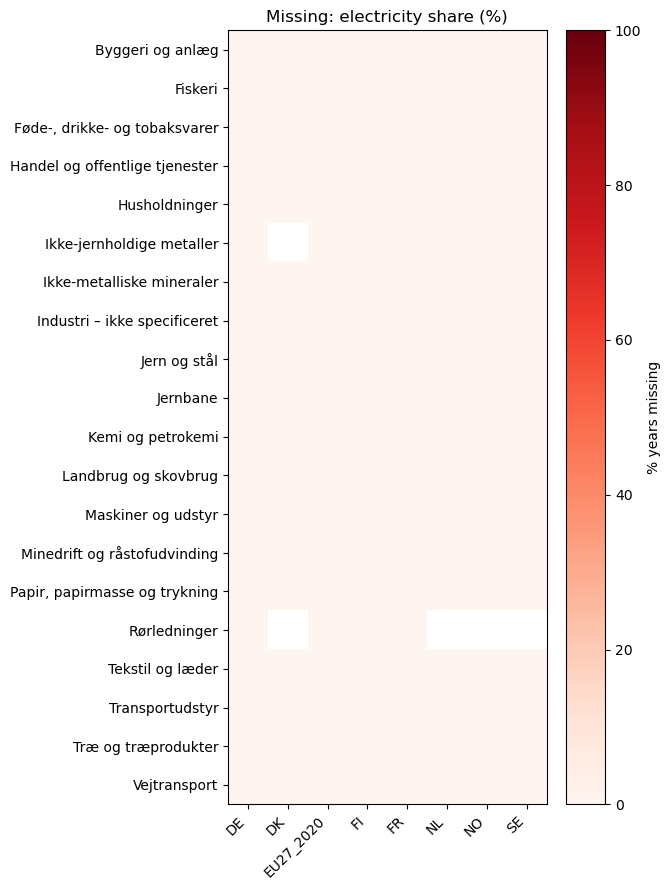

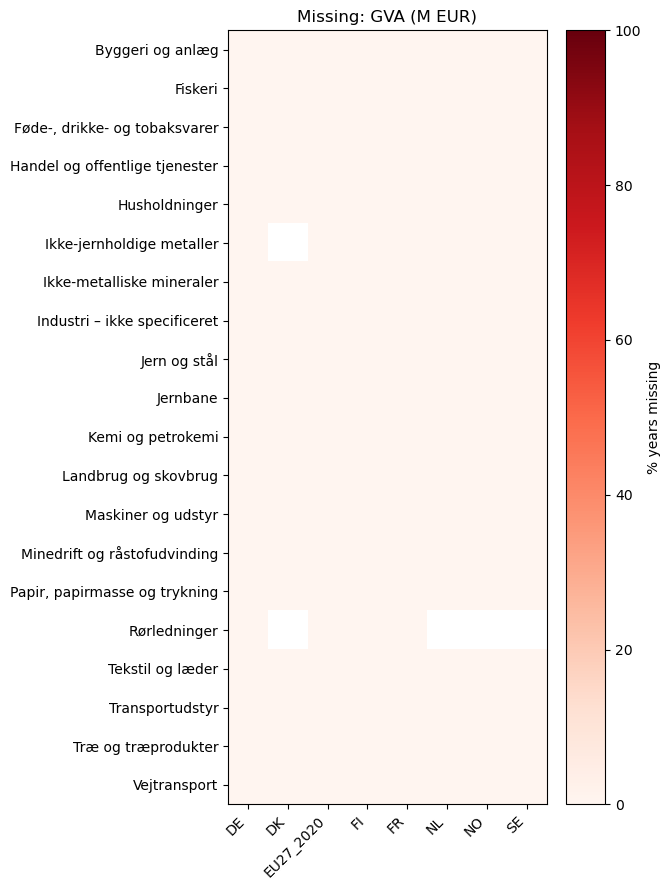

In [8]:
### Missing data: % of years with NaN per (geo × sector)

def missing_heatmap(df, col, title):
    miss = (
        df.groupby(['label', 'geo'])[col]
        .apply(lambda x: x.isna().mean() * 100)
        .unstack('geo')
        .round(1)
    )
    fig, ax = plt.subplots(figsize=(len(miss.columns) * 0.7 + 1, len(miss) * 0.4 + 1))
    im = ax.imshow(miss.values, aspect='auto', cmap='Reds', vmin=0, vmax=100)
    ax.set_xticks(range(len(miss.columns))); ax.set_xticklabels(miss.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(miss.index)));  ax.set_yticklabels(miss.index)
    plt.colorbar(im, ax=ax, label='% years missing')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

missing_heatmap(df, 'elec_share_pct', 'Missing: electricity share (%)')
missing_heatmap(df, 'gva_meur',       'Missing: GVA (M EUR)')